# 🗺️ Fase 1: Análise de Negócios e Segmentação Espacial com Redes de Kohonen (SOM)

## Contexto de Negócio
O objetivo deste notebook é mapear o ecossistema de Churn da empresa através de duas lentes:
1. **Exploração Tradicional:** Identificar padrões visuais de tempo de casa e contratos.
2. **Inteligência Não-Linear:** Utilizar Mapas Auto-Organizáveis (Self-Organizing Maps - SOM) para projetar 36 variáveis comportamentais em uma matriz bidimensional (40x40), agrupando clientes por similaridade de consumo sem supervisão do alvo.

## Output Técnico
Ao final, salvaremos as coordenadas geométricas `(X_som, Y_som)` atreladas a cada cliente para guiar os nossos laboratórios de sub-clusterização regional.

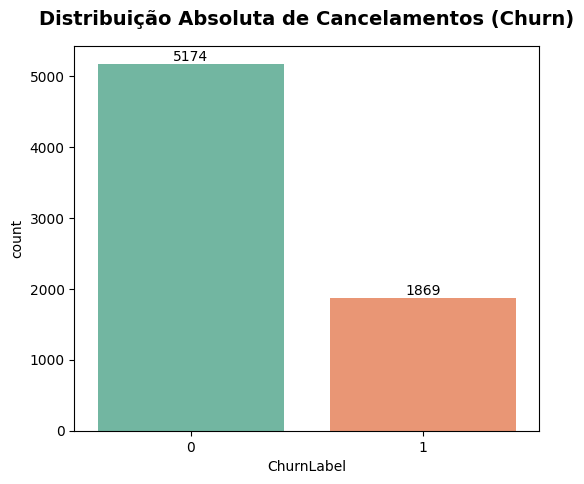

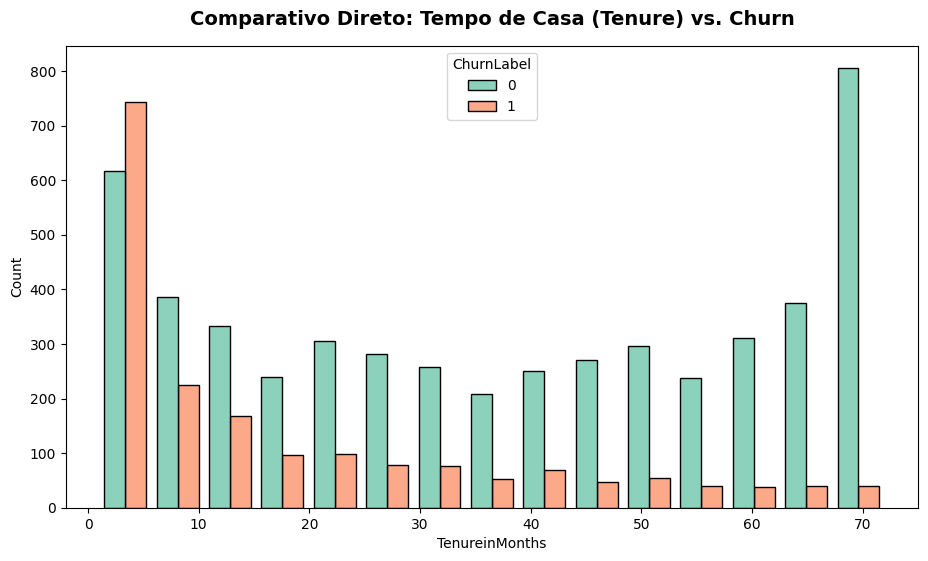


--- Treinando o Mapa de Kohonen (5000 iterações) ---


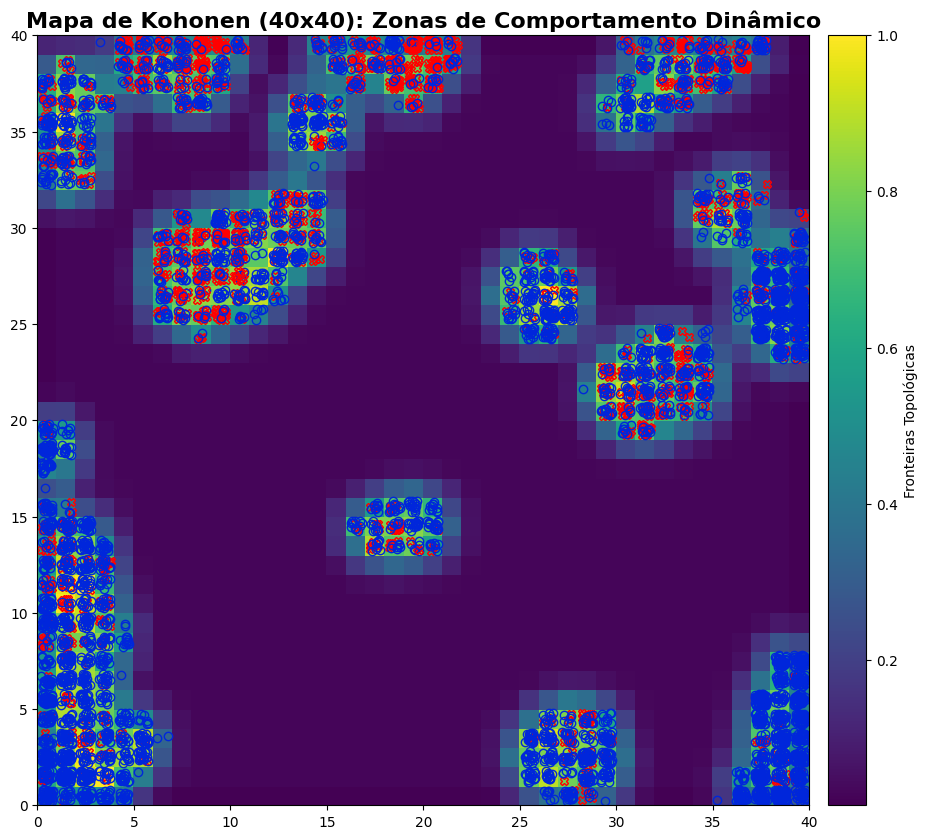


[Sucesso] Direto criado e dataframe com coordenadas espaciais salvo para o Notebook 02!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from minisom import MiniSom
import joblib

# =========================================================================
# 1. CARREGAMENTO E SANEAMENTO DOS DADOS
# =========================================================================
sns.set_theme(style="whitegrid")
plt.style.use('default')

df = pd.read_csv('../data/raw/telco.csv')
df.columns = df.columns.str.replace(' ', '')

df['ChurnCategory'] = df['ChurnCategory'].fillna('None (Active Customer)')
df['ChurnReason'] = df['ChurnReason'].fillna('None (Active Customer)')
df['InternetType'] = df['InternetType'].fillna('No Internet Service')
df['Offer'] = df['Offer'].fillna('No Offer')

df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan).astype(float).fillna(0)
df['ChurnLabel'] = df['ChurnLabel'].map({'Yes': 1, 'No': 0})

# =========================================================================
# 2. GRÁFICOS EXPLORATÓRIOS (PORTFÓLIO)
# =========================================================================
plt.figure(figsize=(6, 5))
ax = sns.countplot(x='ChurnLabel', data=df, hue='ChurnLabel', palette='Set2', legend=False)
plt.title('Distribuição Absoluta de Cancelamentos (Churn)', fontsize=14, fontweight='bold', pad=15)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

plt.figure(figsize=(11, 6))
sns.histplot(data=df, x='TenureinMonths', hue='ChurnLabel', multiple='dodge', palette='Set2', shrink=0.8)
plt.title('Comparativo Direto: Tempo de Casa (Tenure) vs. Churn', fontsize=14, fontweight='bold', pad=15)
plt.show()

# =========================================================================
# 3. PREPARAÇÃO MATRICIAL E NORMALIZAÇÃO PARA O SOM
# =========================================================================
colunas_comportamentais = [
    'Gender', 'Age', 'Under30', 'SeniorCitizen', 'Married', 'Dependents', 'NumberofDependents', 
    'ReferredaFriend', 'NumberofReferrals', 'TenureinMonths', 'Offer', 'PhoneService', 
    'AvgMonthlyLongDistanceCharges', 'MultipleLines', 'InternetService', 'InternetType', 
    'AvgMonthlyGBDownload', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtectionPlan', 
    'PremiumTechSupport', 'StreamingTV', 'StreamingMovies', 'StreamingMusic', 'UnlimitedData', 
    'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharge', 'TotalCharges', 
    'TotalRefunds', 'TotalExtraDataCharges', 'TotalLongDistanceCharges', 'TotalRevenue', 
    'SatisfactionScore', 'CLTV'
]

X_raw = df[colunas_comportamentais].copy()
y = df['ChurnLabel'].values

linhas_validas = ~pd.isna(y)
X_raw_clean = X_raw[linhas_validas]
y_clean = y[linhas_validas].astype(int)

colunas_categoricas = X_raw_clean.select_dtypes(include=['object', 'category']).columns.tolist()
X_encoded = pd.get_dummies(X_raw_clean, columns=colunas_categoricas, drop_first=True)

scaler = MinMaxScaler()
X_scaled_clean = scaler.fit_transform(X_encoded)

# =========================================================================
# 4. TREINAMENTO DO MAPA DE KOHONEN (U-MATRIX)
# =========================================================================
tamanho_x, tamanho_y = 40, 40
som = MiniSom(x=tamanho_x, y=tamanho_y, input_len=X_scaled_clean.shape[1], 
              sigma=0.70, learning_rate=0.5, neighborhood_function='gaussian', random_seed=42)
som.pca_weights_init(X_scaled_clean)

print("\n--- Treinando o Mapa de Kohonen (5000 iterações) ---")
som.train_random(data=X_scaled_clean, num_iteration=5000, verbose=False)

fig, ax = plt.subplots(figsize=(12, 10))
cax = ax.pcolor(som.distance_map().T, cmap='viridis') 
fig.colorbar(cax, ax=ax, pad=0.02).set_label('Fronteiras Topológicas')

markers, colors = ['o', 'X'], ['#0026db', '#ff0000']
rng = np.random.default_rng(42)

for i, x in enumerate(X_scaled_clean):
    w = som.winner(x)
    ax.plot(w[0] + 0.5 + rng.uniform(-0.3, 0.3), w[1] + 0.5 + rng.uniform(-0.3, 0.3), markers[y_clean[i]], 
            markerfacecolor='none', markeredgecolor=colors[y_clean[i]], markersize=6)
plt.title('Mapa de Kohonen (40x40): Zonas de Comportamento Dinâmico', fontsize=16, fontweight='bold')
plt.show()

# =========================================================================
# 5. PONTE DE TRANSIÇÃO: SALVAMENTO DOS DADOS PARA A FASE 2 (BLINDADO)
# =========================================================================
import os

df_analise = df[linhas_validas].copy()
coordenadas_bmu = [som.winner(x) for x in X_scaled_clean]
df_analise['X_som'] = [p[0] for p in coordenadas_bmu]
df_analise['Y_som'] = [p[1] for p in coordenadas_bmu]

# Força o Python a criar a árvore de pastas se ela não existir no seu computador
os.makedirs('../data/processed', exist_ok=True)

# Agora o salvamento vai passar direto sem travar!
joblib.dump(df_analise, '../data/processed/df_com_coordenadas_som.pkl')
print("\n[Sucesso] Diretorio criado e dataframe com coordenadas espaciais salvo para o Notebook 02!")